In [51]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

labels = pd.read_csv('labels.csv', dtype={'track_id': str})


labels

,track_id,track_genre
0,000002,Hip-Hop
1,000005,Hip-Hop
2,000010,Pop
3,000140,Folk
4,000141,Folk
...,...,...
7995,154308,Hip-Hop
7996,154309,Hip-Hop
7997,154413,Pop
7998,154414,Pop


### Interesują nas tylko tracki obecne zarówno w fma_small jak i w labels

In [52]:
import os
print("cwd:", os.getcwd())
FMA_ROOT = Path("..") / "fma_tracks" / "fma_small"
print("FMA_ROOT exists:", FMA_ROOT.exists())


cwd: /Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/PROJEKT
FMA_ROOT exists: True


### Mamy 8000 tracków w fma_small, az 50000 w labels -> inner join

In [53]:
mp3s = list(FMA_ROOT.rglob("*.mp3"))

# mp3 ids (strings)
ids = {p.stem for p in FMA_ROOT.rglob("*.mp3") if p.stem.isdigit() and len(p.stem) == 6}

# labels ids (strings)
label_ids = set(labels["track_id"].astype(str))

# ONE intersection
good_ids = ids & label_ids

# filter labels
labels = labels[labels["track_id"].astype(str).isin(good_ids)].copy()

len(good_ids), labels.shape




(8000, (8000, 2))

In [54]:
labels.to_csv('labels.csv', index = False)

## 1. Class Imbalance

<Axes: xlabel='count', ylabel='track_genre'>

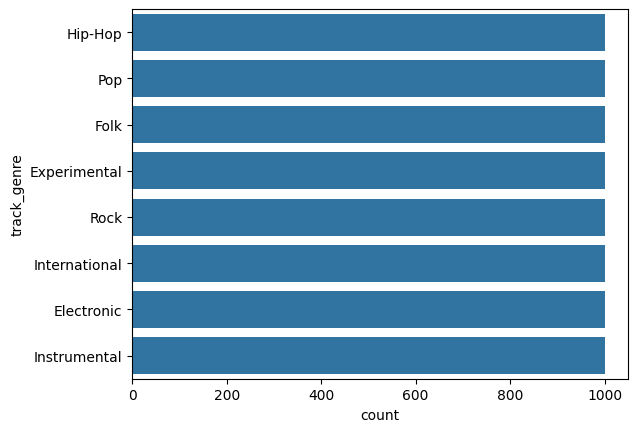

In [55]:
sns.countplot(data = labels, y = 'track_genre')

## 2. Sound statistics

In [56]:
import numpy as np

def spectrogram_stats(X: np.ndarray) -> dict:
    X = X.astype(np.float32)

    x = X.ravel()

    # rozbijam spektrogram na 30 'chunków', na kazdym policzę average energy
    col_chunks = np.array_split(X, 30, axis=1)

    avgfreq = {}
    for i, chunk in enumerate(col_chunks, start=1):
        avgfreq[f"averagefrequency{i}"] = float(np.mean(chunk))

    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "median": float(np.median(x)),
        "q25": float(np.quantile(x, 0.25)),
        "q75": float(np.quantile(x, 0.75)),
        "q90": float(np.quantile(x, 0.90)),
        "energy_mean_sq": float(np.mean(x * x)),          # average energy
        "sparsity_frac0": float(np.mean(x <= 1e-6)),      # fraction ~0
        **avgfreq,
    }


### Tworze spektrogramy

In [57]:
import os
import numpy as np
import librosa
from pydub import AudioSegment

def cut_and_save_logmel_ffmpeg(
    input_path: str,
    output_folder: str,
    track_id: str,
    genre: str | None,
    stats_rows: list,
    seconds: float = 3.0,
    sr: int = 22050,
    n_mels: int = 128,
    n_fft: int = 2048,
    hop_length: int = 512,
    fmin: float = 20.0,
    fmax: float | None = 8000.0,
    top_db: float = 80.0,
    time_bins: int = 128,
    seed: int | None = None,
    n_slices: int = 3,  # NEW: number of non-overlapping slices
):
    """
    Generates n_slices spectrograms per song from non-overlapping `seconds` slices.
    Saves as: {track_id}_s1.npy, {track_id}_s2.npy, {track_id}_s3.npy
    Appends one stats row per slice to stats_rows.
    Returns list of saved paths, or None on failure.
    """
    try:
        audio = AudioSegment.from_file(input_path, format="mp3")
        audio = audio.set_channels(1).set_frame_rate(sr)

        samples = np.array(audio.get_array_of_samples())
        max_val = float(2 ** (8 * audio.sample_width - 1))
        y_full = samples.astype(np.float32) / max_val

        desired_len = int(round(seconds * sr))
        total_needed = n_slices * desired_len
        if len(y_full) < total_needed:
            return None

        rng = np.random.default_rng(seed)
        max_start = len(y_full) - total_needed
        start0 = int(rng.integers(0, max_start + 1))

        fmax_eff = (sr / 2) if fmax is None else min(float(fmax), sr / 2)

        os.makedirs(output_folder, exist_ok=True)
        out_paths = []

        for s_idx in range(n_slices):
            start = start0 + s_idx * desired_len
            y = y_full[start : start + desired_len]

            S = librosa.feature.melspectrogram(
                y=y, sr=sr,
                n_fft=n_fft,
                hop_length=hop_length,
                win_length=n_fft,
                window="hann",
                center=False,
                power=2.0,
                n_mels=n_mels,
                fmin=fmin,
                fmax=fmax_eff,
                htk=False,
                norm="slaney",
            )

            S_db = librosa.power_to_db(S, ref=1.0, top_db=top_db)
            X = (S_db + top_db) / top_db
            X = np.clip(X, 0.0, 1.0)

            # force fixed time dim
            T = X.shape[1]
            if T < time_bins:
                X = np.pad(X, ((0, 0), (0, time_bins - T)), mode="constant", constant_values=0.0)
            else:
                X = X[:, :time_bins]

            if X.shape != (n_mels, time_bins):
                return None
            if not np.isfinite(X).all():
                return None
            if np.max(X) <= 0.0:
                return None

            slice_track_id = f"{track_id}_s{s_idx+1}"
            out_path = os.path.join(output_folder, f"{slice_track_id}.npy")
            np.save(out_path, X.astype(np.float32))
            out_paths.append(out_path)

            row = {"track_id": str(slice_track_id), "genre": genre}
            row.update(spectrogram_stats(X))
            stats_rows.append(row)

        return out_paths

    except Exception:
        return None


In [58]:
import os
import random
import pandas as pd

SEED = 123
TARGET_N = 10_000
stats_rows = []
base_dir = "../fma_tracks/fma_small"
spec_dir = "spectrograms"
output_csv = "good_labels.csv"

os.makedirs(spec_dir, exist_ok=True)
random.seed(SEED)

# --- labels ids as 6-digit strings
labels2 = labels.copy()
labels2["track_id"] = labels2["track_id"].astype(str).str.zfill(6)

# --- collect all mp3 paths and ids (filename stem)
mp3_paths = [
    os.path.join(root, f)
    for root, _, files in os.walk(base_dir)
    for f in files
    if f.lower().endswith(".mp3")
]

mp3_id_to_path = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in mp3_paths
}

mp3_ids = set(mp3_id_to_path.keys())
label_ids = set(labels2["track_id"])

# --- ONE intersection
good_pool = sorted(mp3_ids & label_ids)

# --- sample ids
k = min(TARGET_N, len(good_pool))
sample_ids = random.sample(good_pool, k=k)

id_to_genre = dict(zip(labels2["track_id"], labels2["track_genre"]))

good_slice_ids = []
good_slice_genres = []
bad_ids = []

for i, tid in enumerate(sample_ids, 1):
    path = mp3_id_to_path[tid]
    parent_genre = id_to_genre.get(tid)

    out_paths = cut_and_save_logmel_ffmpeg(
        input_path=path,
        output_folder=spec_dir,
        track_id=tid,
        genre=parent_genre,
        seconds=3.0,
        seed=SEED + int(tid),
        stats_rows=stats_rows,
        n_slices=3,
    )

    if out_paths is None:
        bad_ids.append(tid)
    else:
        for s in range(1, 4):
            good_slice_ids.append(f"{tid}_s{s}")
            good_slice_genres.append(parent_genre)

    if i % 200 == 0:
        print(f"Processed {i}/{k}")

# --- save labels for successful spectrogram slices
used_labels = pd.DataFrame({
    "track_id": good_slice_ids,        # longer ids: 000123_s1 etc.
    "track_genre": good_slice_genres,  # genre from parent track
})
used_labels.to_csv(output_csv, index=False)

pd.DataFrame({"track_id": bad_ids}).to_csv("bad_ids.csv", index=False)

print("Done.")
print("mp3 files:", len(mp3_paths))
print("intersection pool:", len(good_pool))
print("sampled:", len(sample_ids))
print("good tracks:", len(sample_ids) - len(bad_ids))
print("bad tracks:", len(bad_ids))
print("spectrogram slices saved:", len(good_slice_ids))
print("labels rows saved:", len(used_labels))


Processed 200/8000
Processed 400/8000
Processed 600/8000
Processed 800/8000
Processed 1000/8000
Processed 1200/8000
Processed 1400/8000
Processed 1600/8000
Processed 1800/8000
Processed 2000/8000
Processed 2200/8000
Processed 2400/8000
Processed 2600/8000
Processed 2800/8000
Processed 3000/8000
Processed 3200/8000
Processed 3400/8000
Processed 3600/8000
Processed 3800/8000
Processed 4000/8000
Processed 4200/8000
Processed 4400/8000
Processed 4600/8000
Processed 4800/8000
Processed 5000/8000
Processed 5200/8000
Processed 5400/8000
Processed 5600/8000
Processed 5800/8000
Processed 6000/8000
Processed 6200/8000
Processed 6400/8000
Processed 6600/8000
Processed 6800/8000
Processed 7000/8000
Processed 7200/8000
Processed 7400/8000
Processed 7600/8000
Processed 7800/8000
Processed 8000/8000
Done.
mp3 files: 8000
intersection pool: 8000
sampled: 8000
good tracks: 7990
bad tracks: 10
spectrogram slices saved: 23970
labels rows saved: 23970


### Spectrogram - based stats

In [59]:
pd.DataFrame(stats_rows).to_csv("spectrogram_stats.csv", index=False)

In [60]:
spec_stats = pd.read_csv('spectrogram_stats.csv', dtype = {'track_id': str})

spec_stats

,track_id,genre,mean,std,median,q25,q75,q90,energy_mean_sq,sparsity_frac0,...,averagefrequency21,averagefrequency22,averagefrequency23,averagefrequency24,averagefrequency25,averagefrequency26,averagefrequency27,averagefrequency28,averagefrequency29,averagefrequency30
0,010440_s1,Folk,0.788088,0.203717,0.839010,0.643802,0.968802,1.000000,0.662583,0.015625,...,0.819299,0.823405,0.808827,0.814400,0.803586,0.797774,0.802491,0.772009,0.789896,0.377257
1,010440_s2,Folk,0.796636,0.204677,0.854172,0.653071,0.980007,1.000000,0.676521,0.015625,...,0.841136,0.848669,0.810734,0.833933,0.866961,0.859316,0.845654,0.848304,0.846331,0.423329
2,010440_s3,Folk,0.817088,0.197069,0.879431,0.688989,0.993572,1.000000,0.706469,0.015625,...,0.840511,0.855063,0.817993,0.831725,0.845892,0.815720,0.815754,0.838959,0.831947,0.409335
3,053576_s1,Folk,0.717806,0.201835,0.742799,0.623215,0.853289,0.981084,0.555983,0.015625,...,0.784472,0.758827,0.712033,0.747317,0.724639,0.730145,0.757502,0.713396,0.776603,0.391512
4,053576_s2,Folk,0.687823,0.185711,0.688143,0.588996,0.802054,0.948735,0.507589,0.015625,...,0.670938,0.708682,0.664216,0.686491,0.747269,0.700679,0.686273,0.673813,0.662547,0.350345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,145462_s2,Electronic,0.853569,0.131348,0.865957,0.816025,0.919261,0.970861,0.745831,0.015625,...,0.833136,0.818071,0.794785,0.852545,0.830677,0.810935,0.917433,0.873177,0.830769,0.423732
23966,145462_s3,Electronic,0.816751,0.134810,0.834561,0.772745,0.889489,0.936373,0.685257,0.015625,...,0.782081,0.780503,0.881362,0.840071,0.809225,0.786360,0.913187,0.866036,0.800332,0.399044
23967,062180_s1,Instrumental,0.675124,0.221759,0.666841,0.499209,0.858583,1.000000,0.504969,0.015625,...,0.751377,0.734670,0.733847,0.664209,0.650210,0.641521,0.631127,0.646791,0.636651,0.328427
23968,062180_s2,Instrumental,0.650042,0.216381,0.631175,0.490942,0.815490,0.987848,0.469375,0.015625,...,0.665149,0.649405,0.654911,0.635234,0.627281,0.766837,0.667721,0.647145,0.680492,0.326626


In [61]:
spec_stats['genre'].unique()

array(['Folk', 'Rock', 'Instrumental', 'International', 'Pop',
       'Electronic', 'Hip-Hop', 'Experimental'], dtype=object)

In [62]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# --- load your table
df = pd.read_csv("spectrogram_stats.csv")

# features + target
feature_cols = [c for c in df.columns if c not in ("track_id", "genre")]
X = df[feature_cols].to_numpy()
y = df["genre"].astype(str).to_numpy()

# --- 6-fold stratified CV
cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=123)

# kNN benefits from scaling
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=400, weights="distance"))
])



scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print("Fold accuracies:", np.round(scores, 4))
print(f"Mean accuracy: {scores.mean():.4f}  (+/- {scores.std():.4f})")


Fold accuracies: [0.2418 0.2518 0.2478 0.2303 0.2375 0.2378]
Mean accuracy: 0.2412  (+/- 0.0071)


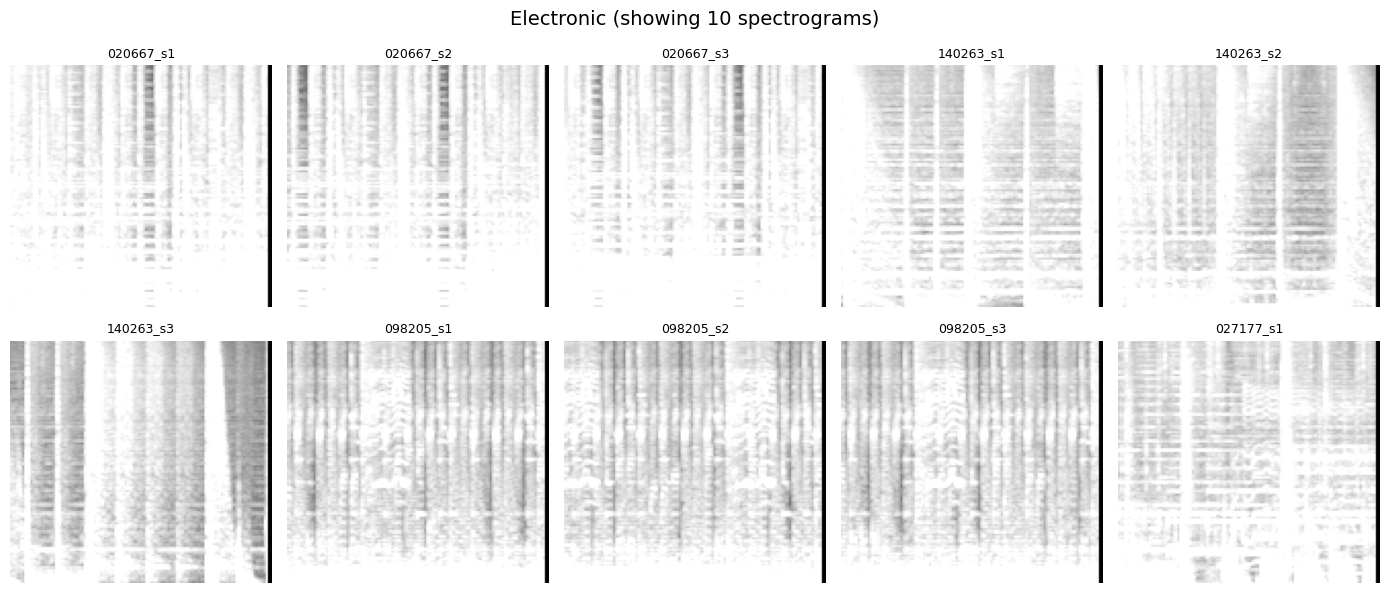

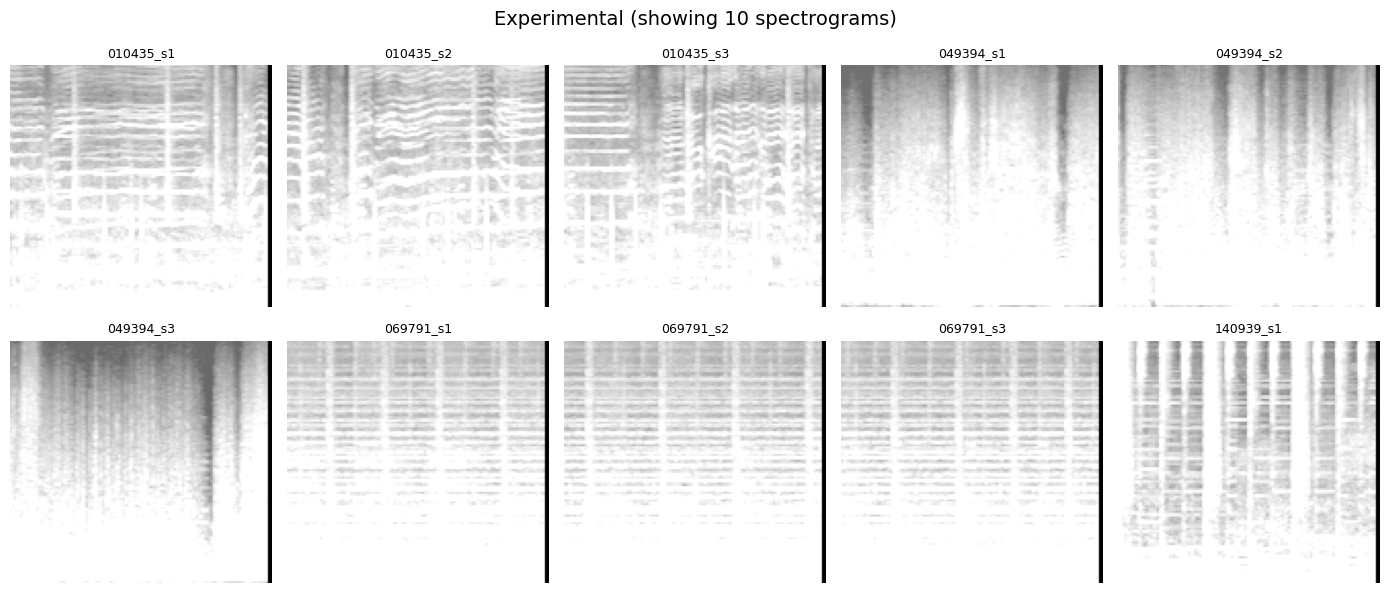

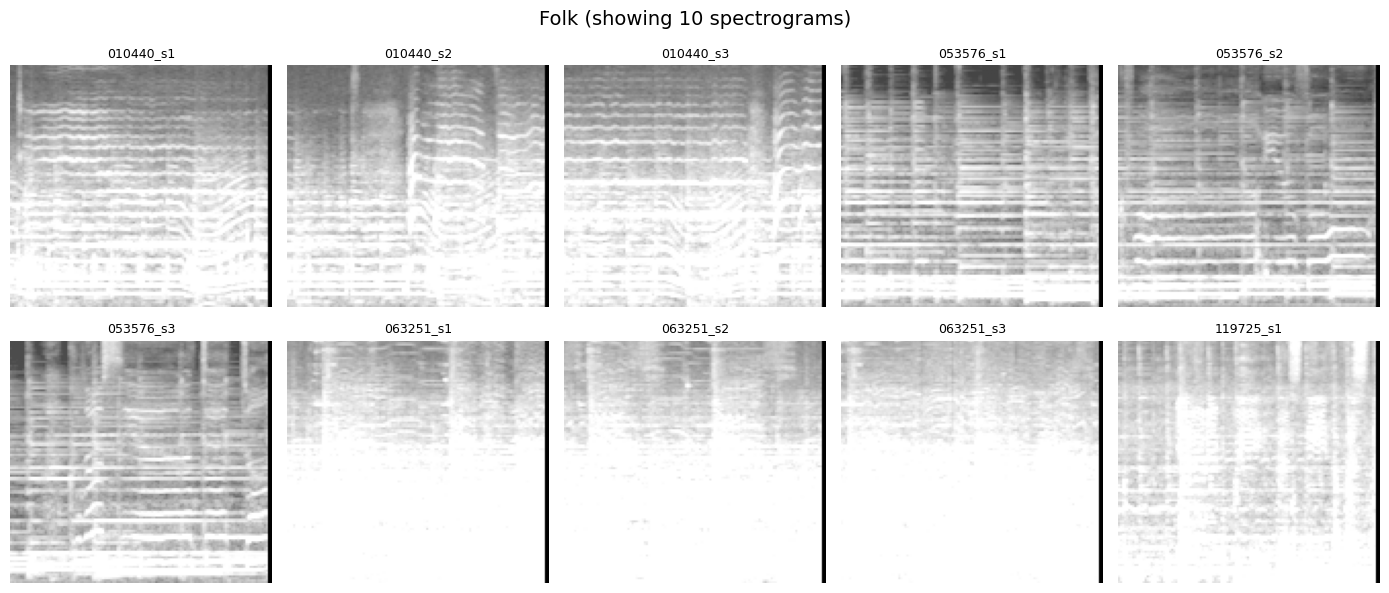

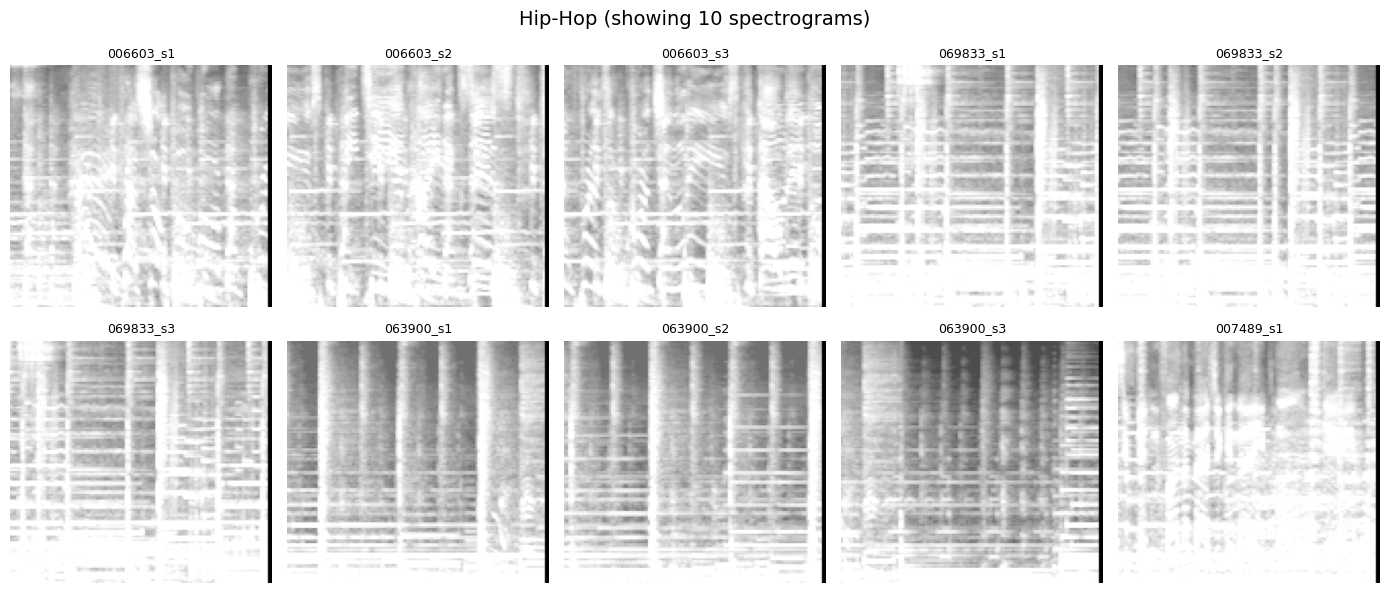

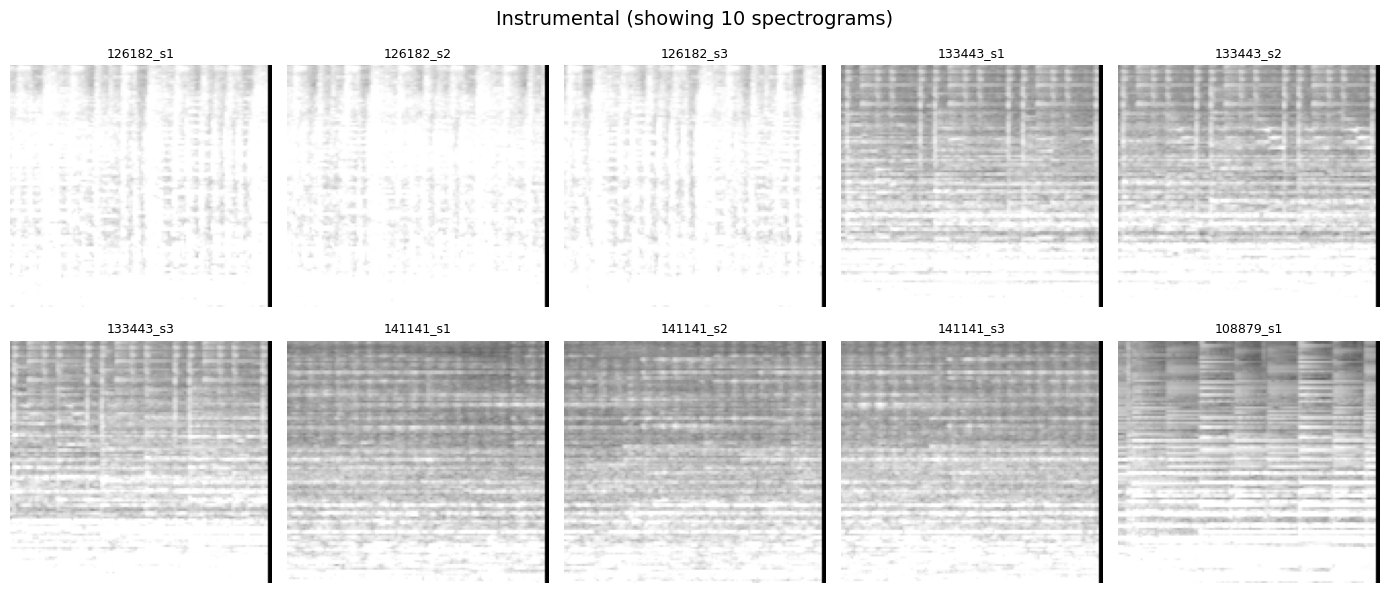

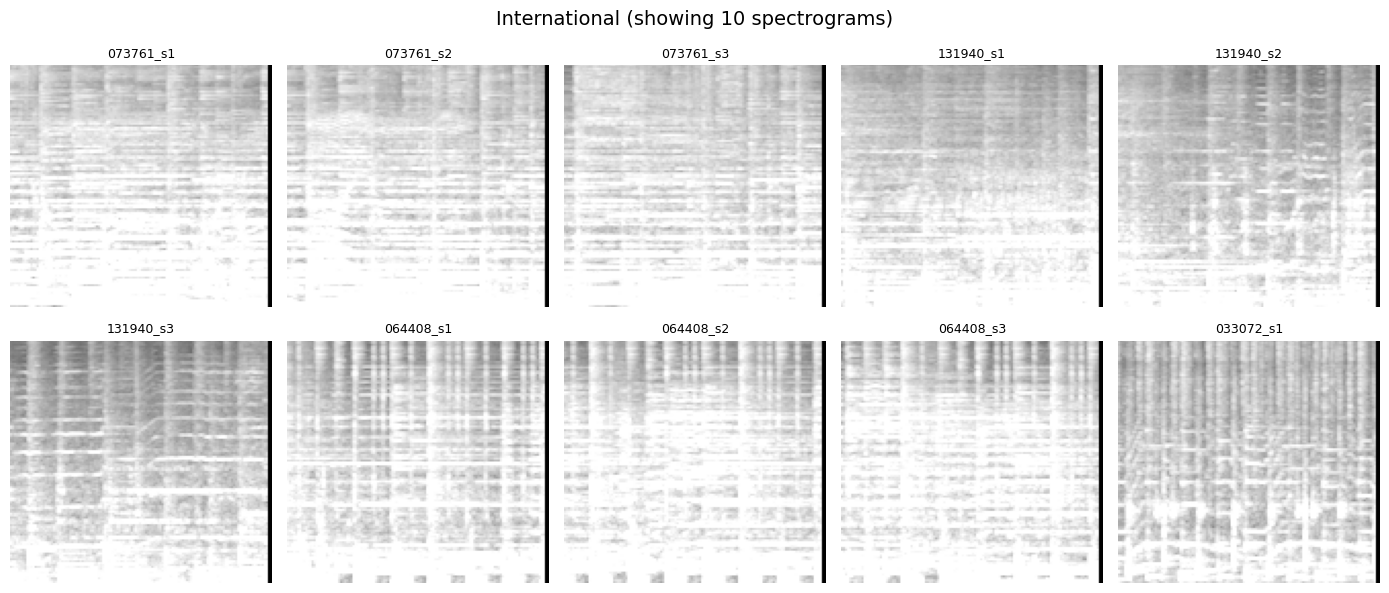

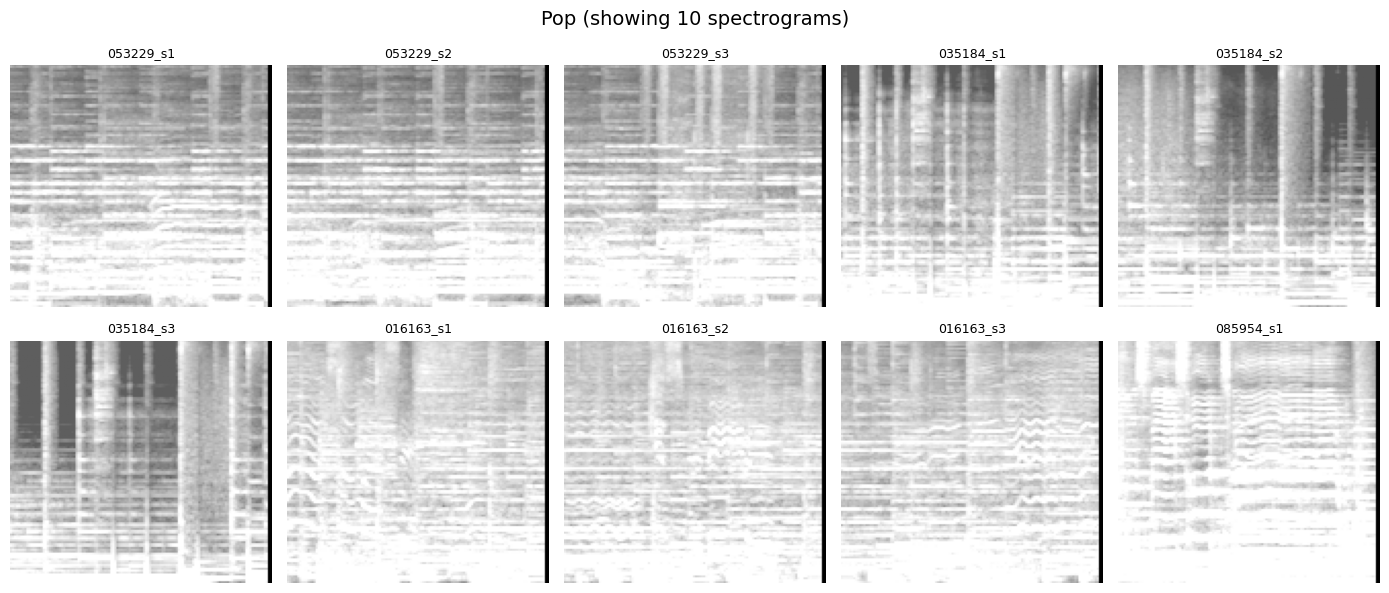

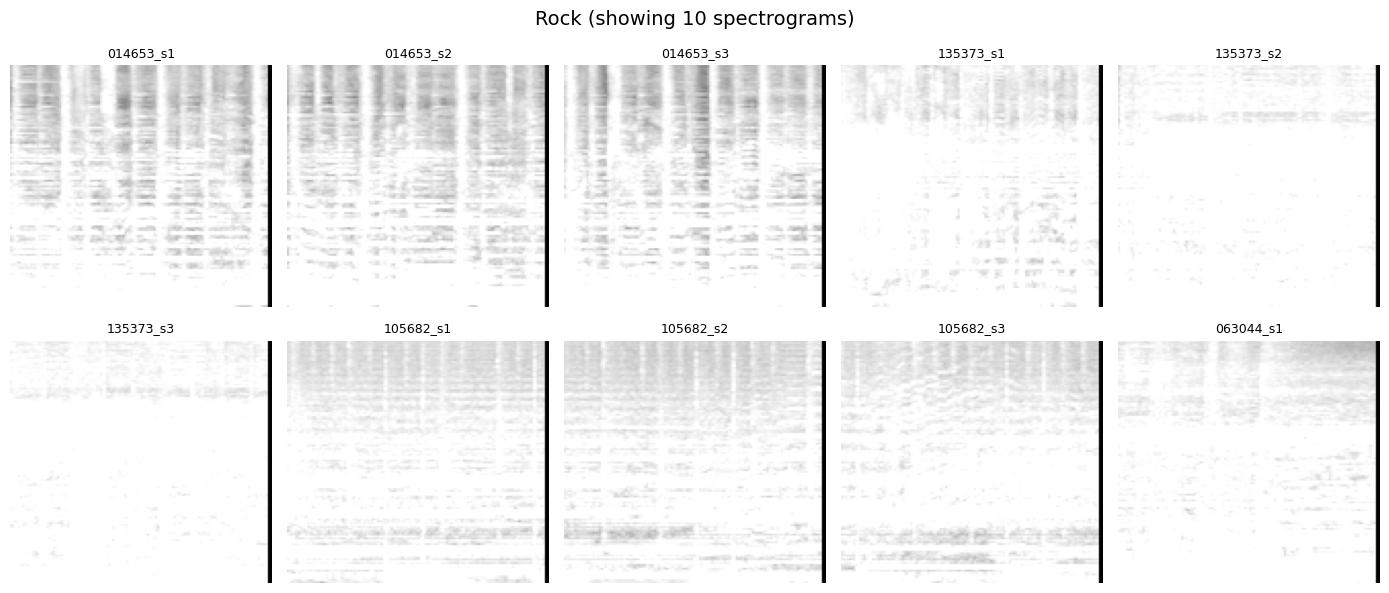

In [63]:

import matplotlib.pyplot as plt


# paths
STATS_CSV = Path("spectrogram_stats.csv")
SPEC_DIR  = Path("spectrograms")      # where 000123.npy lives

# load table
df = pd.read_csv(STATS_CSV)
df["track_id"] = df["track_id"].astype(str).str.zfill(6)
df["genre"] = df["genre"].astype(str)

# for each genre: pick up to 10 ids and plot
for genre, gdf in df.groupby("genre"):
    ids = gdf["track_id"].dropna().astype(str).unique()[:10]
    if len(ids) == 0:
        continue

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    axes = axes.ravel()
    fig.suptitle(f"{genre} (showing {len(ids)} spectrograms)", fontsize=14)

    for ax, tid in zip(axes, ids):
        path = SPEC_DIR / f"{tid}.npy"
        if not path.exists():
            ax.set_title(f"{tid} (missing)")
            ax.axis("off")
            continue

        X = np.load(path)  # (n_mels, time_bins)
        ax.imshow(X, aspect="auto", origin="lower", cmap = 'grey')  # X already in [0,1]
        ax.set_title(tid, fontsize=9)
        ax.axis("off")

    # hide unused axes if <10
    for ax in axes[len(ids):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
